In [1]:
"""
Utilities for loading and analyzing recorded activations.

Example usage:
	from analysis.load_activations import load_episodes, plot_latent_trajectory
	
	episodes = load_episodes('analysis/activations/dog-run_seed1')
	plot_latent_trajectory(episodes[0])
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pickle
import json

# Add parent directory to path for imports
sys.path.append("/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")
sys.path.append("/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/analysis/")
from common.activation_recorder import load_episode, load_all_episodes

In [2]:
from load_activations import plot_latent_trajectory, plot_latent_space_2d, plot_latent_pca, plot_action_distributions, print_episode_summary, get_latent_stats

In [3]:
data_dir = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2025-10-24/16-42-30/analysis/activations/cartpole-swingup_seed1'

In [4]:
# Load episodes
print(f"Loading episodes from {data_dir}...")
episodes = load_all_episodes(data_dir)

if len(episodes) == 0:
    print("No episodes found!")
    sys.exit(1)

# Print summary
print("\n" + "=" * 60)
print("Dataset Summary")
print("=" * 60)
print(f"Number of episodes: {len(episodes)}")
total_steps = sum(ep['metadata']['episode_length'] for ep in episodes)
print(f"Total steps: {total_steps}")
mean_reward = np.mean([ep['metadata']['total_reward'] for ep in episodes])
std_reward = np.std([ep['metadata']['total_reward'] for ep in episodes])
print(f"Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")
print("=" * 60)

# Print first episode details
print("\nFirst episode details:")
print_episode_summary(episodes[0])


Loading episodes from /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2025-10-24/16-42-30/analysis/activations/cartpole-swingup_seed1...
Loaded 1 episodes from /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2025-10-24/16-42-30/analysis/activations/cartpole-swingup_seed1

Dataset Summary
Number of episodes: 1
Total steps: 500
Mean reward: 882.64 ± 0.00

First episode details:
Episode 0
Task: cartpole-swingup
Length: 500 steps
Total Reward: 882.64
Success: False
Checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/ckpts/cartpole-swingup-3.pt
Timestamp: 2025-10-24T16:42:44.448047
------------------------------------------------------------
Latent shape: (500, 512)
Latent mean: 0.1250
Latent std: 0.1884
Actions shape: (500, 1)
Action mean: [0.00016187]
Action std: [0.3324037]


In [5]:
# Get latent statistics
print("\nLatent statistics across all episodes:")
stats = get_latent_stats(episodes)
print(f"Shape: {stats['shape']}")
print(f"Mean (first 5 dims): {stats['mean'][:5]}")
print(f"Std (first 5 dims): {stats['std'][:5]}")


Latent statistics across all episodes:
Shape: (500, 512)
Mean (first 5 dims): [0.01784335 0.19437137 0.55160105 0.03029201 0.03345575]
Std (first 5 dims): [0.0206635  0.05890486 0.18453097 0.01090981 0.03151128]


In [6]:
episodes[0]['data'].keys()

dict_keys(['observations', 'actions', 'rewards', 'dones', 'latent_states', 'timesteps'])

In [7]:
obs = episodes[0]['data']['observations']
obs_stacked = np.stack(obs)

In [8]:
actions = episodes[0]['data']['actions']
actions_stacked = np.stack(actions)


In [29]:
latents = episodes[0]['data']['latent_states']
latents_stacked = np.stack(latents).squeeze()


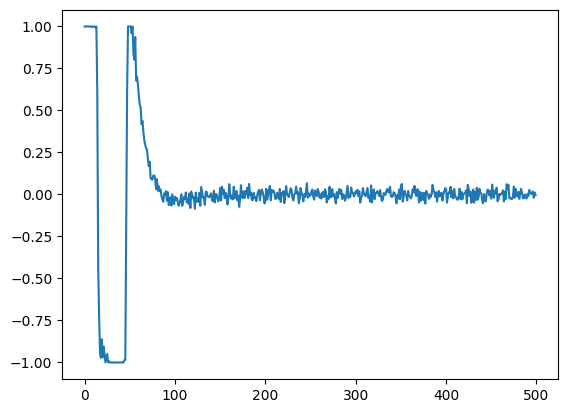

In [10]:
plt.plot(actions_stacked)

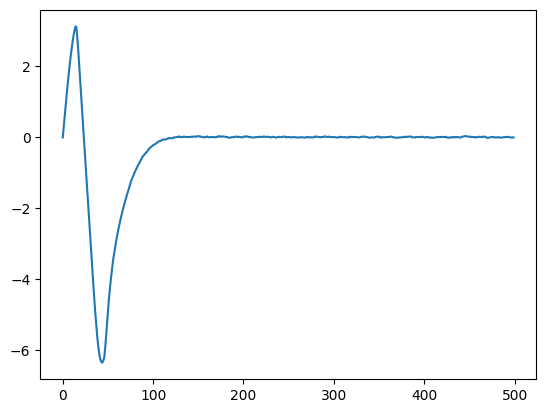

In [11]:
plt.plot(obs_stacked[:, 4])

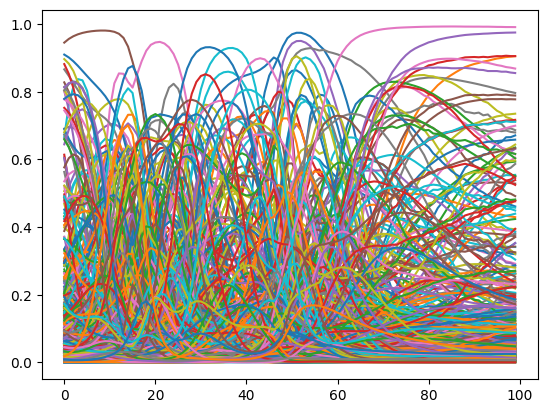

In [12]:
plt.plot(latents_stacked.squeeze()[:100])

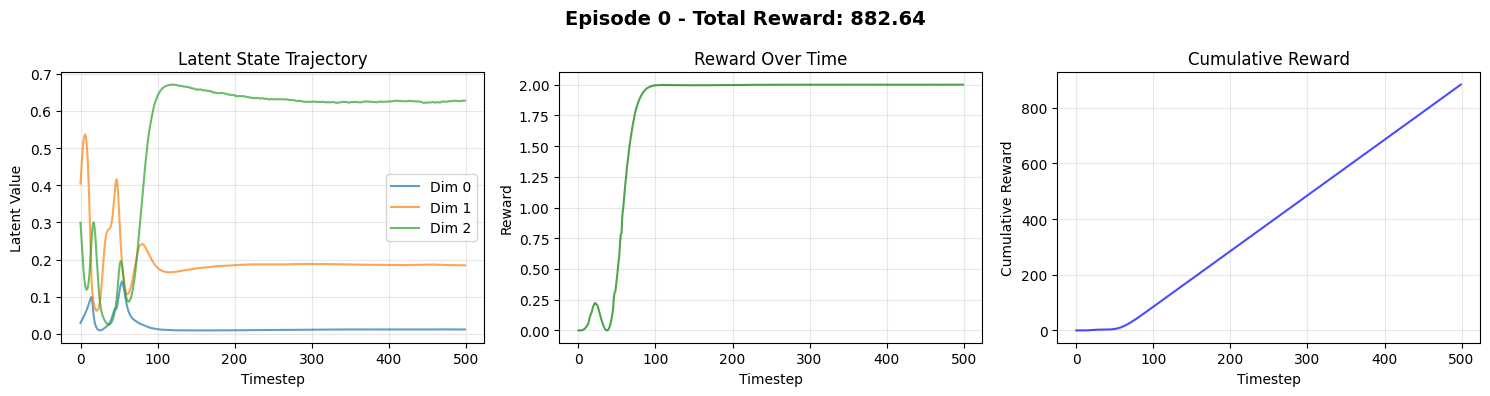

In [13]:
# Plot first episode trajectory
fig = plot_latent_trajectory(episodes[0])


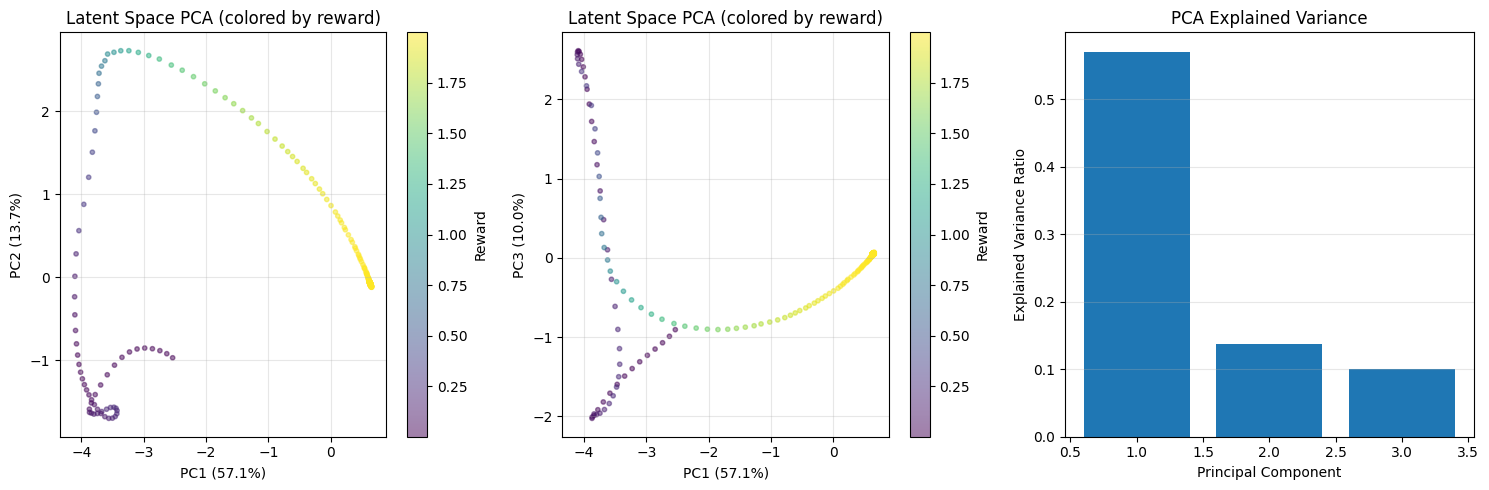

In [14]:
fig, pca = plot_latent_pca(episodes)


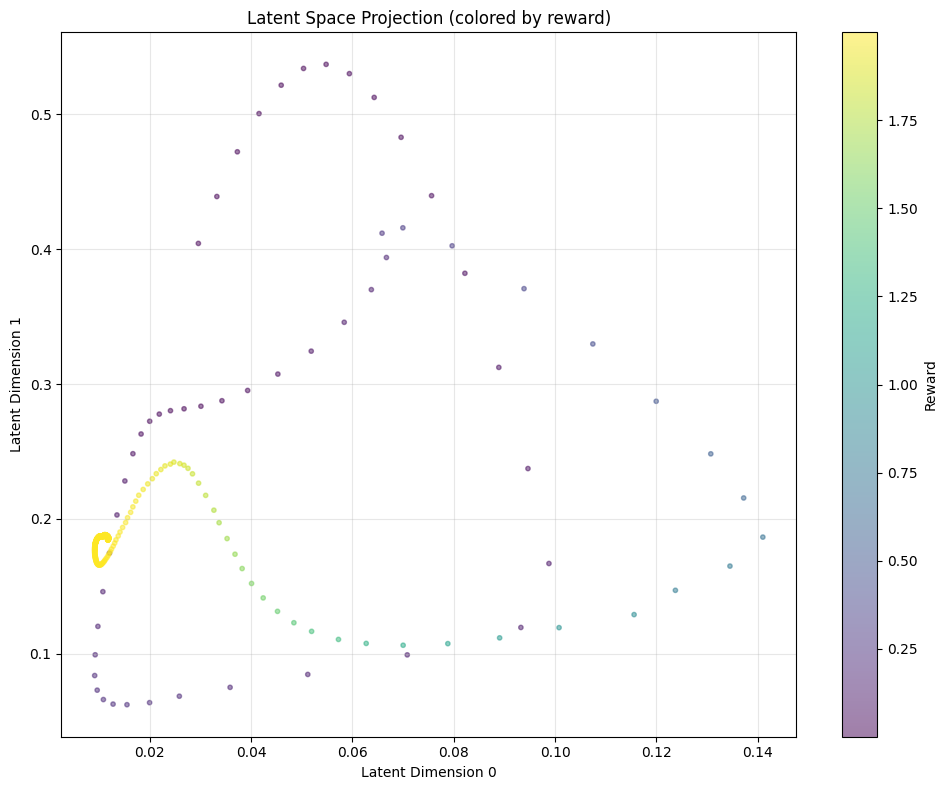

In [15]:
fig = plot_latent_space_2d(episodes, dim1=0, dim2=1, color_by='reward')


In [22]:
latents_pca = pca.fit_transform(latents_stacked.squeeze())

fig = plt.figure(figsize=(18, 5))

<Figure size 1800x500 with 0 Axes>

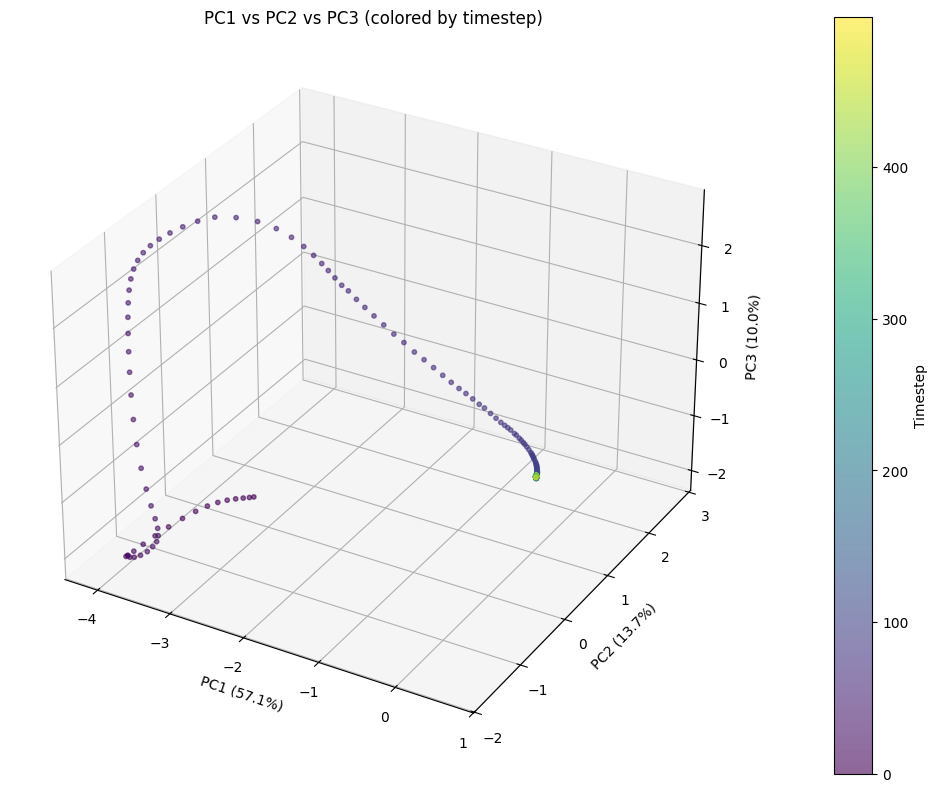

In [27]:
from mpl_toolkits.mplot3d import Axes3D

# Color by time (timestep)
timesteps = episodes[0]['data']['timesteps']
# Ensure timesteps length matches latents_pca
if len(timesteps) > latents_pca.shape[0]:
    timesteps = timesteps[:latents_pca.shape[0]]
elif len(timesteps) < latents_pca.shape[0]:
    timesteps = np.pad(timesteps, (0, latents_pca.shape[0] - len(timesteps)),
                       'constant')

fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(1, 1, 1, projection='3d')
p1 = ax1.scatter(latents_pca[:, 0],
                 latents_pca[:, 1],
                 latents_pca[:, 2],
                 c=timesteps,
                 s=10,
                 alpha=0.6,
                 cmap='viridis')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax1.set_title('PC1 vs PC2 vs PC3 (colored by timestep)')
fig.colorbar(p1, ax=ax1, pad=0.1, label='Timestep')

plt.tight_layout()
plt.show()


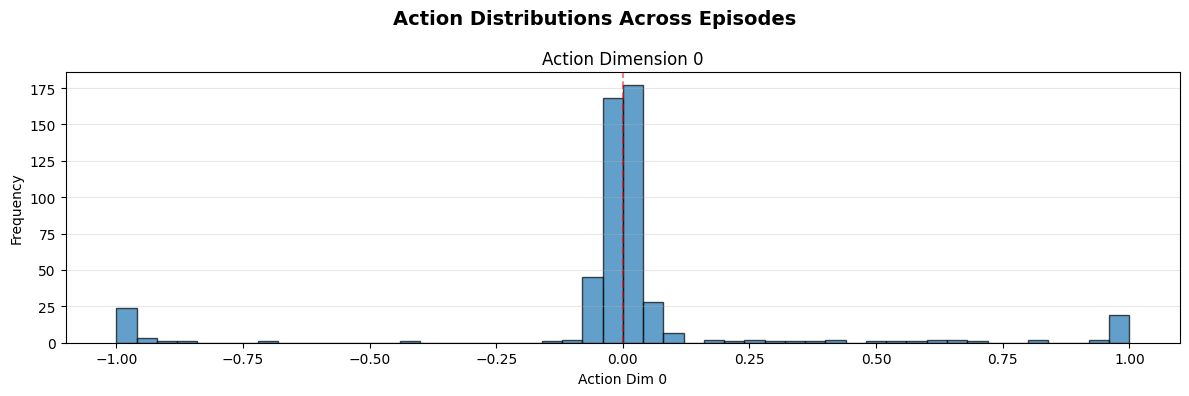

In [16]:
fig = plot_action_distributions(episodes)


In [32]:
all_actions.shape

(500, 1)

In [33]:
n_action

1

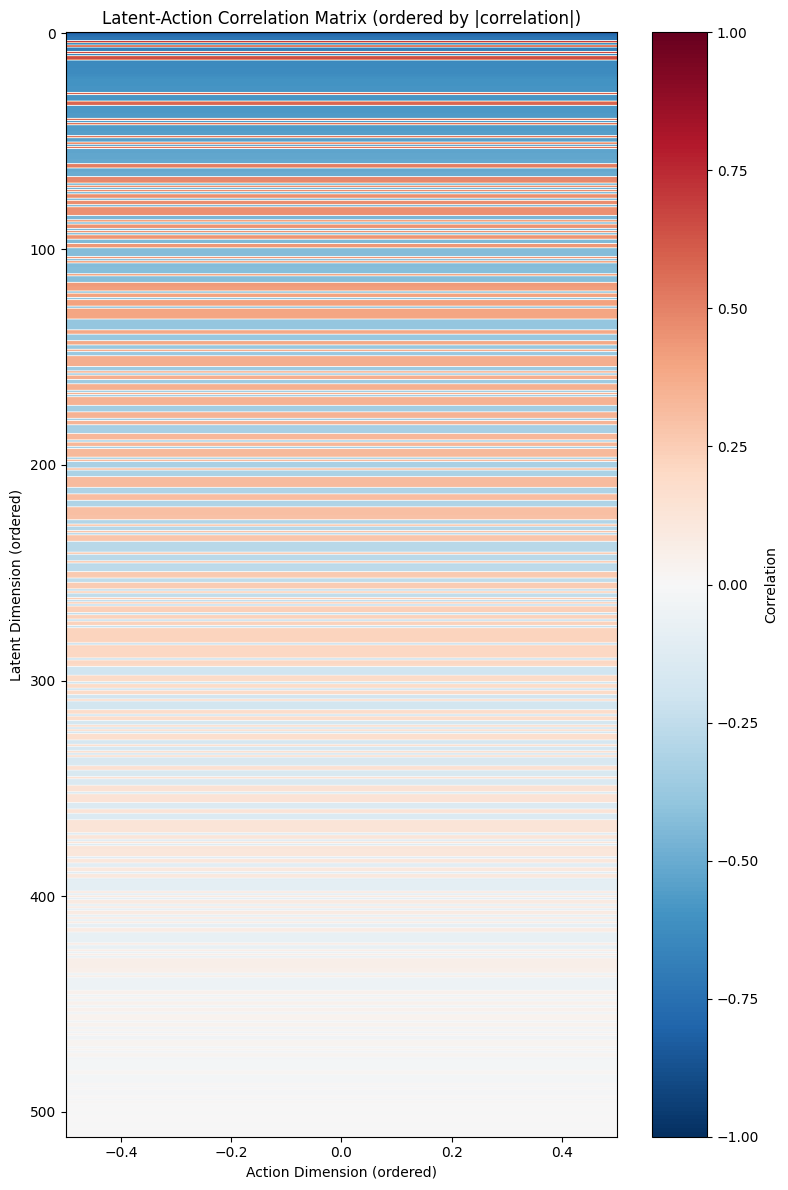

Latent 3 ↔ Action 0: -0.512
Latent 6 ↔ Action 0: 0.511
Latent 7 ↔ Action 0: -0.570
Latent 18 ↔ Action 0: -0.639
Latent 19 ↔ Action 0: -0.547
Latent 44 ↔ Action 0: -0.585
Latent 47 ↔ Action 0: 0.566
Latent 56 ↔ Action 0: -0.603
Latent 68 ↔ Action 0: -0.566
Latent 69 ↔ Action 0: 0.587
Latent 76 ↔ Action 0: -0.563
Latent 83 ↔ Action 0: -0.510
Latent 84 ↔ Action 0: -0.599
Latent 89 ↔ Action 0: -0.570
Latent 92 ↔ Action 0: 0.720
Latent 116 ↔ Action 0: -0.626
Latent 125 ↔ Action 0: 0.534
Latent 129 ↔ Action 0: -0.713
Latent 138 ↔ Action 0: 0.644
Latent 141 ↔ Action 0: -0.597
Latent 147 ↔ Action 0: -0.521
Latent 148 ↔ Action 0: -0.641
Latent 155 ↔ Action 0: -0.577
Latent 165 ↔ Action 0: -0.591
Latent 168 ↔ Action 0: -0.513
Latent 182 ↔ Action 0: 0.542
Latent 184 ↔ Action 0: -0.556
Latent 193 ↔ Action 0: -0.529
Latent 207 ↔ Action 0: -0.545
Latent 209 ↔ Action 0: -0.521
Latent 217 ↔ Action 0: -0.615
Latent 218 ↔ Action 0: -0.720
Latent 222 ↔ Action 0: 0.561
Latent 227 ↔ Action 0: -0.629
Latent

In [35]:
from scipy.stats import pearsonr
# Compute correlation matrix: latent dims × action dims
all_actions = np.concatenate([ep['data']['actions'] for ep in episodes])

n_latent = min(5000, latents_stacked.shape[1])  # Check first 50 dims
n_action = all_actions.shape[1]

corr_matrix = np.zeros((n_latent, n_action))
for i in range(n_latent):
    for j in range(n_action):
        corr_matrix[i, j], _ = pearsonr(latents_stacked[:, i], all_actions[:,
                                                                           j])

# Visualize
import matplotlib.pyplot as plt
import numpy as np

# Order latent dimensions by their maximal absolute correlation to any action dim
latent_order = np.argsort(-np.max(np.abs(corr_matrix), axis=1))
# Order action dimensions by their maximal absolute correlation to any latent dim
action_order = np.argsort(-np.max(np.abs(corr_matrix), axis=0))

corr_ordered = corr_matrix[latent_order][:, action_order]

plt.figure(figsize=(8, 12))
plt.imshow(corr_ordered, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xlabel('Action Dimension (ordered)')
plt.ylabel('Latent Dimension (ordered)')
plt.title('Latent-Action Correlation Matrix (ordered by |correlation|)')
plt.tight_layout()
plt.show()

# Find strongest connections
threshold = 0.5
for i in range(n_latent):
    for j in range(n_action):
        if abs(corr_matrix[i, j]) > threshold:
            print(f"Latent {i} ↔ Action {j}: {corr_matrix[i, j]:.3f}")

## Correlation between latent diemnsions and observations

latents_pca shape: (500, 10)


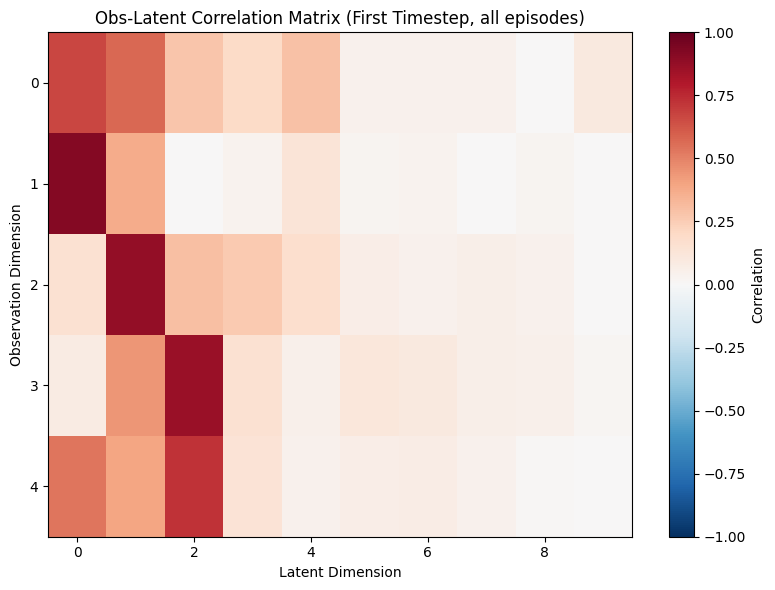

In [50]:
# Correlation matrix between observation and latents, for one time step (t=0)
from scipy.stats import pearsonr
import numpy as np

from sklearn.decomposition import PCA

# Reduce latents_stacked to 5 principal components (dims) using PCA
n_pca_dims = 10
pca = PCA(n_components=n_pca_dims)
latents_pca = pca.fit_transform(latents_stacked)
print("latents_pca shape:", latents_pca.shape)

obs_dim = obs_stacked.shape[1]
latent_dim = latents_pca.shape[1]
corr_matrix_first = np.zeros((obs_dim, latent_dim))
for i in range(obs_dim):
    for j in range(latent_dim):
        corr_matrix_first[i, j], _ = pearsonr(obs_stacked[:, i], latents_pca[:,
                                                                             j])

plt.figure(figsize=(8, 6))
plt.imshow(abs(corr_matrix_first),
           cmap='RdBu_r',
           vmin=-1,
           vmax=1,
           aspect='auto',
           interpolation='none')
plt.colorbar(label='Correlation')
plt.xlabel('Latent Dimension')
plt.ylabel('Observation Dimension')
plt.title('Obs-Latent Correlation Matrix (First Timestep, all episodes)')
plt.tight_layout()
plt.show()

# # Now compute for all time steps (all transitions concatenated)
# # obs_stacked: [N, obs_dim], latents_stacked: [N, latent_dim]
# corr_matrix_all = np.zeros((obs_dim, latent_dim))
# for i in range(obs_dim):
#     for j in range(latent_dim):
#         corr_matrix_all[i, j], _ = pearsonr(obs_stacked[:, i], latents_stacked[:, j])

# plt.figure(figsize=(10, 7))
# plt.imshow(corr_matrix_all, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
# plt.colorbar(label='Correlation')
# plt.xlabel('Latent Dimension')
# plt.ylabel('Observation Dimension')
# plt.title('Obs-Latent Correlation Matrix (All Steps)')
# plt.tight_layout()
# plt.show()

# # Optionally: print strongest correlations
# threshold = 0.5
# print("Strongest Obs-Latent Correlations (All Steps):")
# for i in range(obs_dim):
#     for j in range(latent_dim):
#         if abs(corr_matrix_all[i, j]) > threshold:
#             print(f"Obs {i} ↔ Latent {j}: {corr_matrix_all[i, j]:.3f}")